# Modelos Autorregressivos (AR) em Séries Temporais

Nesta aula iremos entender esses processos fundamentais, suas propriedades e como identificá-los visualmente através das Funções de Autocorrelação (FAC) e Autocorrelação Parcial (FACP) que é um passo indispensável para abordar modelos mais complexos como ARMA e ARIMA.

### 0. Importando as Bibliotecas Essenciais

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import statsmodels.api as sm 
from statsmodels.tsa.stattools import adfuller, kpss 
from statsmodels.tsa.ar_model import AutoReg 
from statsmodels.tsa.arima.model import ARIMA 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
from sklearn.metrics import mean_absolute_error, mean_squared_error 
from scipy.stats import shapiro

# Configurações globais para melhorar a visualização dos gráficos
plt.rcParams['figure.figsize'] = (15, 6) 
plt.style.use('seaborn-v0_8-darkgrid') 
sns.set_palette('deep') 


## 1. Modelos Autorregressivos (AR)

Um **Processo Autorregressivo de ordem $p$**, denotado por **AR($p$)**, postula que o valor atual de uma série temporal ($X_t$) é uma função linear de seus $p$ valores anteriores ($X_{t-1}, X_{t-2}, \dots, X_{t-p}$), somado a um termo de erro aleatório. A designação "autorregressivo" deriva do fato de que a variável dependente (o valor atual) está sendo regredida em seus próprios valores passados.

### 1.1. Formulação Matemática do AR($p$)

A forma geral de um AR($p$) é:

$$X_t = c + \phi_1 X_{t-1} + \phi_2 X_{t-2} + \dots + \phi_p X_{t-p} + \epsilon_t$$ 

Onde:
- $X_t$: É o valor observado da série temporal no instante $t$.
- $c$: Representa uma constante (ou intercepto), que está relacionada à média da série se ela for estacionária e não tivermos um termo de média móvel.
- $\phi_1, \phi_2, \dots, \phi_p$: São os **coeficientes autorregressivos**. Eles quantificam a influência de cada valor passado ($X_{t-k}$) sobre o valor atual da série. Quanto maior o valor absoluto de $\phi_k$, maior a dependência do $k$-ésimo lag.
- $\epsilon_t$: É o **termo de erro (ou ruído branco)** no tempo $t$. Assume-se que $\epsilon_t$ são variáveis aleatórias independentes e identicamente distribuídas (i.i.d.) com média zero e variância constante $\sigma^2$ (ou seja, $\epsilon_t \sim N(0, \sigma^2)$ se assumimos normalidade). O ruído branco não possui autocorrelação.

#### Condição de Estacionariedade para AR($p$)
Para que um processo AR($p$) seja **estacionário**, as raízes do seu polinômio característico devem estar fora do círculo unitário. Isso garante que a influência dos choques passados (erros) diminua ao longo do tempo, resultando em uma série com média, variância e estrutura de autocovariância que não mudam com o tempo. Por exemplo, para um AR(1), $|\phi_1| < 1$; para um AR(2), as condições são: $\phi_1 + \phi_2 < 1$, $\phi_2 - \phi_1 < 1$ e $|\phi_2| < 1$.

### 1.2. Identificação da Ordem $p$ de um Processo AR através da FAC e FACP

A determinação da ordem $p$ de um processo AR estacionário é realizada pela inspeção cuidadosa dos gráficos da Função de Autocorrelação (FAC) e da Função de Autocorrelação Parcial (FACP).

- **Função de Autocorrelação (FAC)**: A FAC de um processo AR($p$) estacionário é caracterizada por um **decaimento gradual**, que pode ser exponencial (monotônico) ou senoidal (oscilatório e amortecido), tendendo a zero à medida que o lag aumenta. Não exibe um corte abrupto (ou *cutoff*).
- **Função de Autocorrelação Parcial (FACP)**: A FACP de um processo AR($p$) exibe autocorrelações parciais **significativamente diferentes de zero apenas para os primeiros $p$ lags**. A partir do lag $p+1$, as autocorrelações parciais teoricamente são nulas (caem para dentro dos limites de significância). Essa característica de "corte abrupto" (ou *cutoff*) é o principal critério para identificar a ordem $p$ de um modelo AR.

### 1.3. Exemplo: Simulação e Análise de um Processo AR(2)

Vamos simular uma série temporal que segue um processo AR(2). Para este exemplo, definimos os parâmetros da seguinte forma:

$$X_t = 0.5 X_{t-1} + 0.4 X_{t-2} + \epsilon_t$$ 
Onde $\epsilon_t \sim N(0, 9)$ (ruído branco com média 0 e variância 9, ou desvio padrão 3).

Os coeficientes $\phi_1 = 0.5$ e $\phi_2 = 0.4$ foram escolhidos para garantir que o processo seja estacionário.

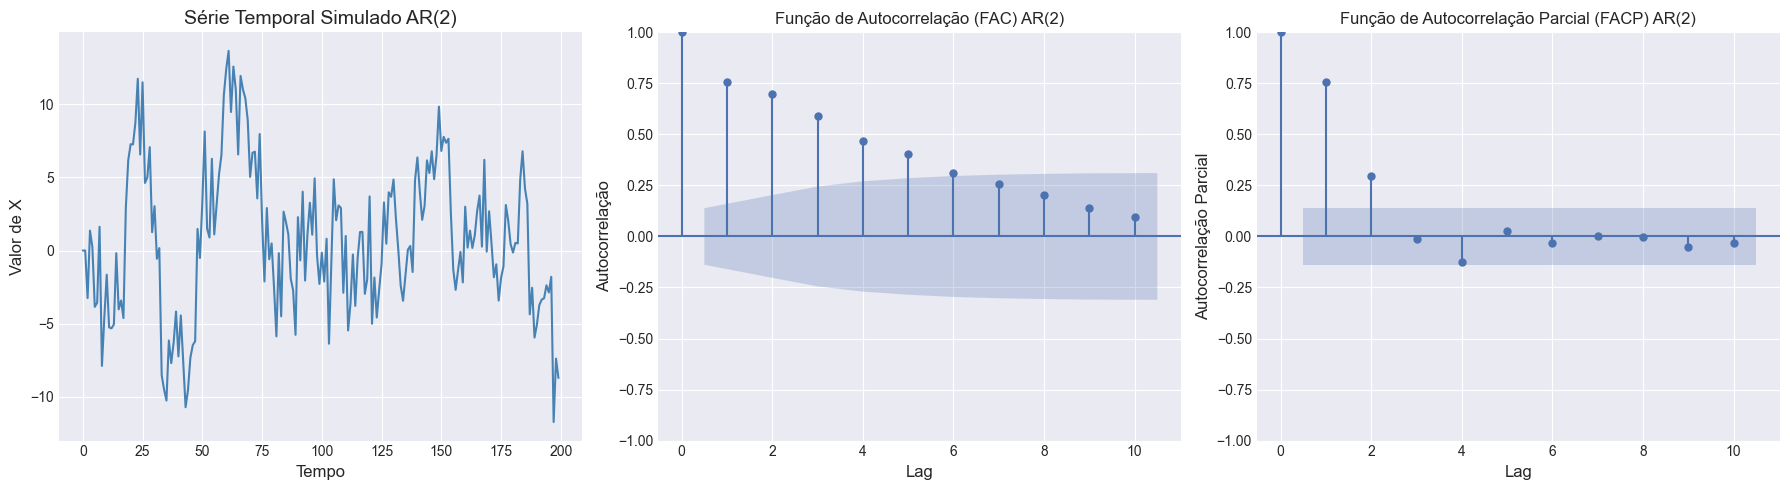

In [2]:
np.random.seed(123) 
n_obs = 200 
X_ar2 = np.zeros(n_obs) 
phi1 = 0.5 
phi2 = 0.4 
sigma_epsilon_ar2 = np.sqrt(9) 

# Laço para simular o processo AR(2) recursivamente
for i in range(2, n_obs): # Começa do índice 2, pois X[i-1] e X[i-2] são necessários
    # A equação do AR(2): X_t = phi1 * X_{t-1} + phi2 * X_{t-2} + epsilon_t
    X_ar2[i] = phi1 * X_ar2[i-1] + phi2 * X_ar2[i-2] + np.random.normal(0, sigma_epsilon_ar2)


df_ar2 = pd.DataFrame({'Valor': X_ar2, 'Tempo': range(n_obs)})

plt.figure(figsize=(18, 5)) 

plt.subplot(1, 3, 1) 
sns.lineplot(data=df_ar2, x='Tempo', y='Valor', color='steelblue') 
plt.title('Série Temporal Simulado AR(2)', fontsize=14)
plt.xlabel('Tempo', fontsize=12)
plt.ylabel('Valor de X', fontsize=12)

plt.subplot(1, 3, 2) 
plot_acf(X_ar2, lags=10, ax=plt.gca(), title='Função de Autocorrelação (FAC) AR(2)') 
plt.xlabel('Lag', fontsize=12)
plt.ylabel('Autocorrelação', fontsize=12)

plt.subplot(1, 3, 3) 
plot_pacf(X_ar2, lags=10, ax=plt.gca(), title='Função de Autocorrelação Parcial (FACP) AR(2)') 
plt.xlabel('Lag', fontsize=12)
plt.ylabel('Autocorrelação Parcial', fontsize=12)

plt.tight_layout() 
plt.show()


**Interpretação dos Resultados para o Processo AR(2):**
- **Série Temporal (Gráfico 1)**: Visualmente, a série `X_ar2` oscila em torno de uma média constante (próxima de zero), sem tendência aparente ou mudanças drásticas na variabilidade, confirmando o comportamento estacionário.
- **Função de Autocorrelação (FAC - Gráfico 2)**: Observa-se que as autocorrelações decaem gradualmente à medida que o lag aumenta. Não há um corte abrupto, o que é consistente com a natureza de um processo AR.
- **Função de Autocorrelação Parcial (FACP - Gráfico 3)**: Este é o gráfico chave para identificar a ordem $p$ de um AR. Notamos que as autocorrelações parciais são **significativamente diferentes de zero apenas para os lags 1 e 2**, e depois caem abruptamente para dentro dos limites de significância (a área sombreada azul). Essa característica de "corte" após o lag 2 confirma a ordem **$p=2$** para nosso processo AR.
- **Testes de Estacionariedade (KPSS e ADF)**: Ambos os testes devem confirmar que a série simulada é estacionária, validando nossa interpretação dos gráficos de autocorrelação e a natureza do processo AR(2) que construímos.


### Testes Estatísticos para Validar o Modelo AR

Temos que verificar se nossos resíduos são:

-   Normais

-   Independentes

-   Estacionários

### 1.4. Testes de Estacionariedade para a Série AR(2)

A estacionariedade é uma suposição crucial para modelos AR. Embora tenhamos construído a série para ser estacionária, é boa prática verificar isso com testes estatísticos.

- **Teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin)**:
    - **Hipótese Nula (H0)**: A série é estacionária 
    - **Hipótese Alternativa (Ha)**: A série não é estacionária 
    - Um p-valor menor que o nível de significância (e.g., 0.05) leva à rejeição de H0, indicando **não estacionariedade**.

- **Teste ADF (Augmented Dickey-Fuller)**:
    - **Hipótese Nula (H0)**: A série *não* é estacionária 
    - **Hipótese Alternativa (Ha)**: A série é estacionária.
    - Um p-valor menor que o nível de significância (e.g., 0.05) leva à rejeição de H0, indicando **estacionariedade**.

Ambos os testes são complementares. Para confirmar a estacionariedade, esperamos que o KPSS *não rejeite* H0 (p-valor > 0.05) e o ADF *rejeite* H0 (p-valor <= 0.05).

In [3]:
# Executando o Teste KPSS
kpss_result_ar2 = kpss(X_ar2, regression='c', nlags='auto') 
print('**Teste KPSS para o Processo AR(2) Simulado:**')
print(f'Estatística do Teste: {kpss_result_ar2[0]:.4f}')
print(f'p-valor: {kpss_result_ar2[1]:.4f}')
print('Valores Críticos (Nível de Significância):')
for key, value in kpss_result_ar2[3].items():
    print(f'  {key}: {value:.4f}')
print('\nResultado do KPSS:')
if kpss_result_ar2[1] < 0.05:
    print('Rejeitamos H0: A série NÃO é estacionária (significativa no nível de 5%).')
else:
    print('Falhamos em rejeitar H0: A série É estacionária (não significativa no nível de 5%).')


**Teste KPSS para o Processo AR(2) Simulado:**
Estatística do Teste: 0.0794
p-valor: 0.1000
Valores Críticos (Nível de Significância):
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390

Resultado do KPSS:
Falhamos em rejeitar H0: A série É estacionária (não significativa no nível de 5%).


C:\Users\p0131335\AppData\Local\Temp\ipykernel_25196\2773117529.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result_ar2 = kpss(X_ar2, regression='c', nlags='auto')


In [4]:
adf_result_ar2 = adfuller(X_ar2, autolag='AIC') 
print('**Teste ADF para o Processo AR(2) Simulado:**')
print(f'Estatística do Teste: {adf_result_ar2[0]:.4f}')
print(f'p-valor: {adf_result_ar2[1]:.4f}')
print(f'Número de lags usados: {adf_result_ar2[2]}')
print(f'Número de observações usadas para regressão ADF: {adf_result_ar2[3]}')
print('Valores Críticos (Nível de Significância):')
for key, value in adf_result_ar2[4].items():
    print(f'  {key}: {value:.4f}')
print('Resultado do ADF:')
if adf_result_ar2[1] <= 0.05:
    print('Rejeitamos H0: A série É estacionária (significativa no nível de 5%).')
else:
    print('Falhamos em rejeitar H0: A série NÃO é estacionária (não significativa no nível de 5%).')

**Teste ADF para o Processo AR(2) Simulado:**
Estatística do Teste: -3.4945
p-valor: 0.0081
Número de lags usados: 3
Número de observações usadas para regressão ADF: 196
Valores Críticos (Nível de Significância):
  1%: -3.4642
  5%: -2.8764
  10%: -2.5747
Resultado do ADF:
Rejeitamos H0: A série É estacionária (significativa no nível de 5%).


### Análise de resíduo para a Série AR(2)

In [5]:
#análise de Resíduos
def plot_acf_pacf(series, lags=10, title=''):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].plot(series)
    axes[0].set_title(f'Série Temporal - {title}')
    plot_acf(series, lags=lags, ax=axes[1])
    plot_pacf(series, lags=lags, ax=axes[2])
    plt.tight_layout()
    plt.show()

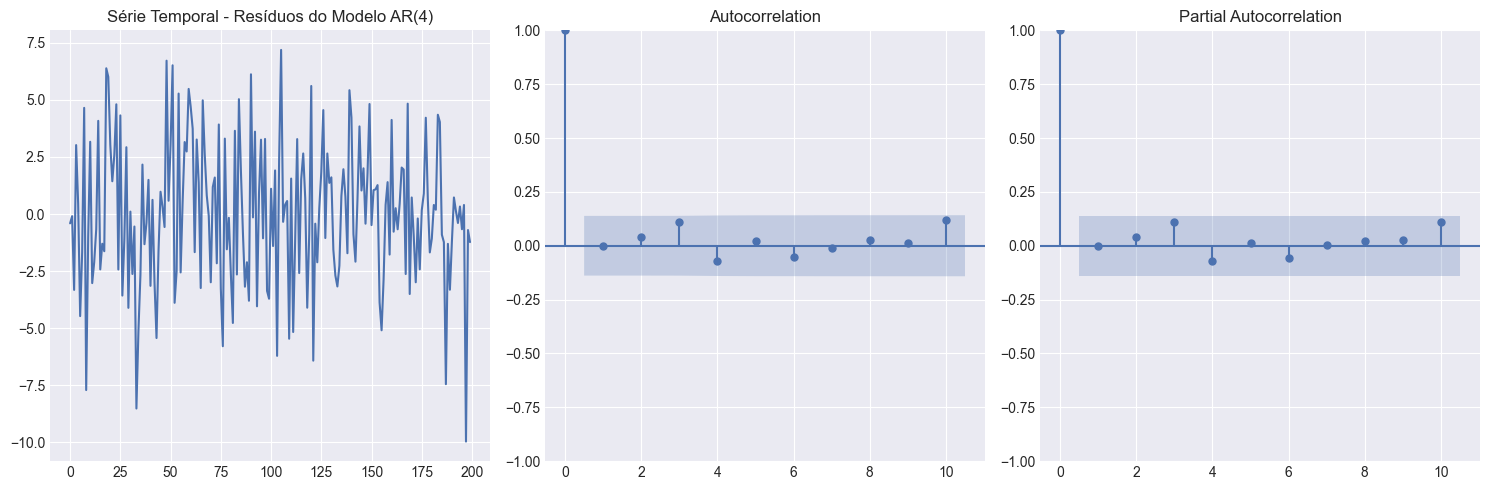

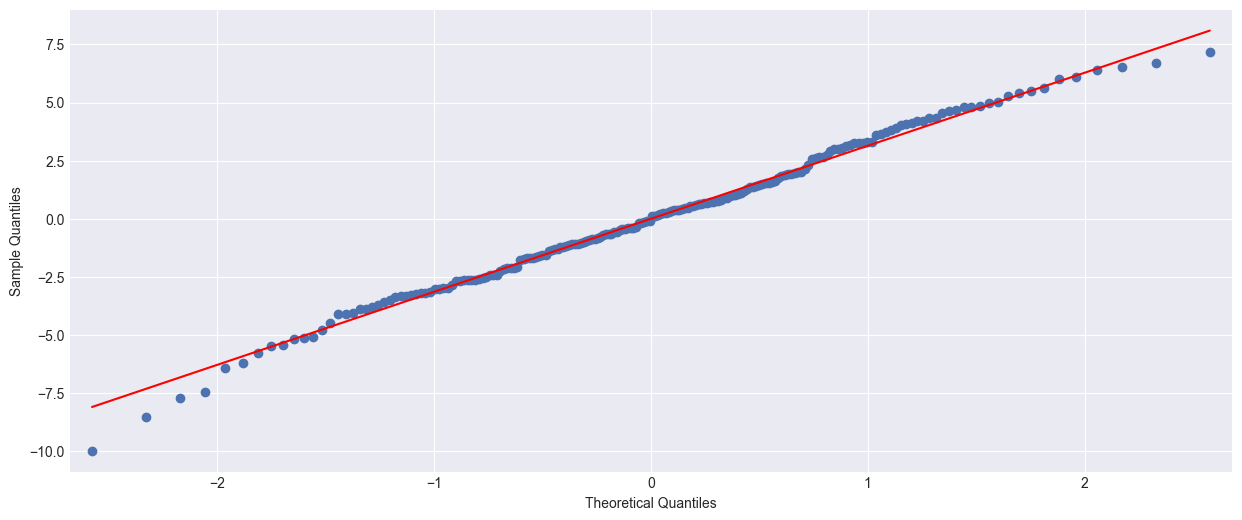

In [6]:
AR_model = ARIMA(X_ar2, order=(2, 0, 0)).fit()
E_AR = AR_model.resid
plot_acf_pacf(E_AR, title='Resíduos do Modelo AR(4)')
sm.qqplot(E_AR, line='s')
plt.show()

### Teste de Independência - Ljung-Box
Quando p-valor > 0,05 temos independencia dos resíduos

In [7]:
ljung_box_result = sm.stats.acorr_ljungbox(E_AR, lags=[20], return_df=True)
print('Teste de Independência - Ljung-Box:')
print(ljung_box_result)

Teste de Independência - Ljung-Box:
      lb_stat  lb_pvalue
20  35.000365   0.020102


#### Teste de Normalidade - Shapiro-Wilk

In [8]:
shapiro_stat, shapiro_p_value = shapiro(E_AR)
print('Teste de Normalidade - Shapiro-Wilk:')
print(f'Estatística do teste: {shapiro_stat:.4f}')
print(f'p-valor: {shapiro_p_value:.4f}')

Teste de Normalidade - Shapiro-Wilk:
Estatística do teste: 0.9932
p-valor: 0.4917


### 1.5. Exemplo: Simulação e Análise de um Processo AR(3)

Para solidificar a compreensão, vamos agora simular um processo AR(3) e observar suas características.
$$X_t = 0.3 X_{t-1} + 0.4 X_{t-2} + 0.2 X_{t-3} + \epsilon_t$$ 
Onde $\epsilon_t \sim N(0, 3)$.

**Simulação do processo AR(3)**

In [9]:
np.random.seed(200) 
n_obs = 200
X_ar3 = np.zeros(n_obs)
phi1_ar3 = 0.2
phi2_ar3 = 0.3
phi3_ar3 = 0.3
sigma_epsilon_ar3 = np.sqrt(3)

for i in range(3, n_obs): # Começa do índice 3 para acessar X[i-1], X[i-2], X[i-3]
    X_ar3[i] = phi1_ar3 * X_ar3[i-1] + phi2_ar3 * X_ar3[i-2] + phi3_ar3 * X_ar3[i-3] + np.random.normal(0, sigma_epsilon_ar3)

df_ar3 = pd.DataFrame({'Valor': X_ar3, 'Tempo': range(n_obs)})

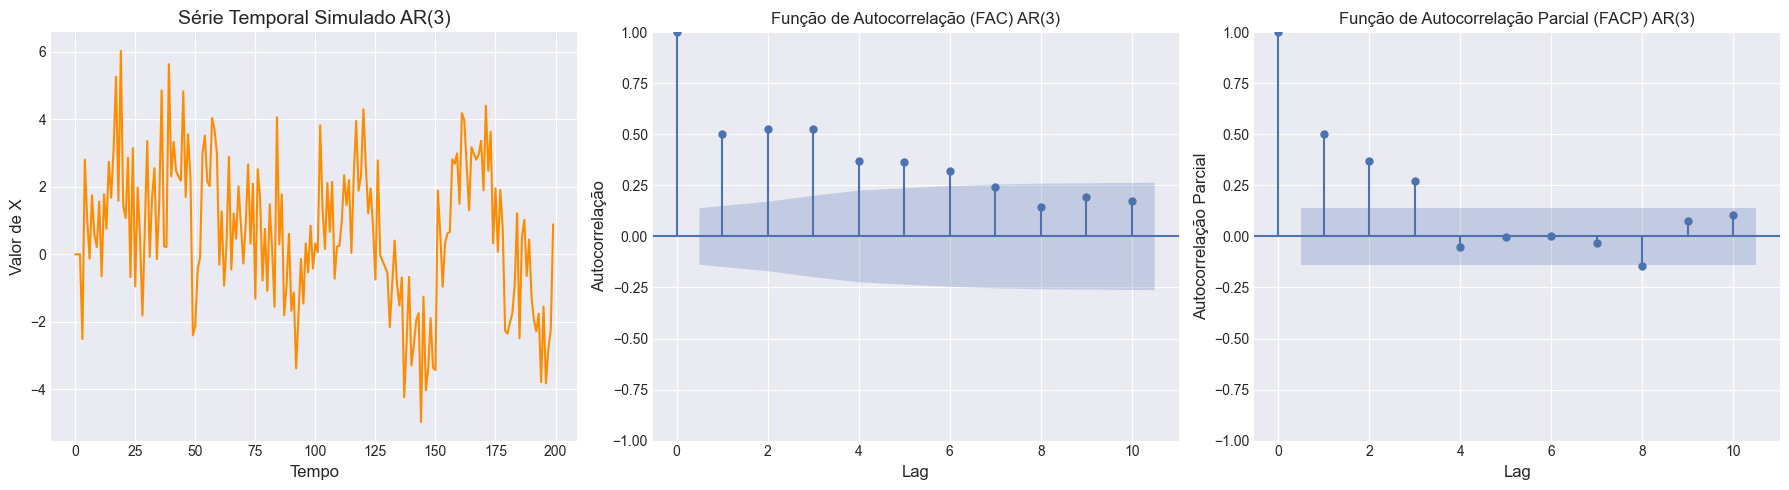

In [10]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.lineplot(data=df_ar3, x='Tempo', y='Valor', color='darkorange')
plt.title('Série Temporal Simulado AR(3)', fontsize=14)
plt.xlabel('Tempo', fontsize=12)
plt.ylabel('Valor de X', fontsize=12)

plt.subplot(1, 3, 2)
plot_acf(X_ar3, lags=10, ax=plt.gca(), title='Função de Autocorrelação (FAC) AR(3)')
plt.xlabel('Lag', fontsize=12)
plt.ylabel('Autocorrelação', fontsize=12)

plt.subplot(1, 3, 3)
plot_pacf(X_ar3, lags=10, ax=plt.gca(), title='Função de Autocorrelação Parcial (FACP) AR(3)')
plt.xlabel('Lag', fontsize=12)
plt.ylabel('Autocorrelação Parcial', fontsize=12)

plt.tight_layout()
plt.show()


**Interpretação dos Resultados para o Processo AR(3):**
- A **FAC** da série AR(3) também mostra o decaimento gradual, característico de processos AR.
- A **FACP** exibe autocorrelações parciais significativas para os **lags 1, 2 e 3**, e depois os valores caem para dentro dos limites de não significância. Isso é o corte abrupto que confirma a ordem **$p=3$** para este processo AR.
- Os **testes de estacionariedade** devem novamente indicar que a série é estacionária, validando a análise de autocorrelação.

### 1.6. Testes de Estacionariedade para a Série AR(3)

In [11]:
# Executando o Teste KPSS
kpss_result_ar3 = kpss(X_ar3, regression='c', nlags='auto')
print('**Teste KPSS para o Processo AR(3) Simulado:**')
print(f'Estatística do Teste: {kpss_result_ar3[0]:.4f}')
print(f'p-valor: {kpss_result_ar3[1]:.4f}')
print('Valores Críticos (Nível de Significância):')
for key, value in kpss_result_ar3[3].items():
    print(f'  {key}: {value:.4f}')
print('\nResultado do KPSS:')
if kpss_result_ar3[1] < 0.05:
    print('Rejeitamos H0: A série NÃO é estacionária (significativa no nível de 5%).')
else:
    print('Falhamos em rejeitar H0: A série É estacionária (não significativa no nível de 5%).')

print('\n' + '='*70 + '\n')


**Teste KPSS para o Processo AR(3) Simulado:**
Estatística do Teste: 0.4089
p-valor: 0.0733
Valores Críticos (Nível de Significância):
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390

Resultado do KPSS:
Falhamos em rejeitar H0: A série É estacionária (não significativa no nível de 5%).




In [12]:
adf_result_ar3 = adfuller(X_ar3, autolag='AIC')
print('**Teste ADF para o Processo AR(3) Simulado:**')
print(f'Estatística do Teste: {adf_result_ar3[0]:.4f}')
print(f'p-valor: {adf_result_ar3[1]:.4f}')
print(f'Número de lags usados: {adf_result_ar3[2]}')
print(f'Número de observações usadas para regressão ADF: {adf_result_ar3[3]}')
print('Valores Críticos (Nível de Significância):')
for key, value in adf_result_ar3[4].items():
    print(f'  {key}: {value:.4f}')
print('Resultado do ADF:')
if adf_result_ar3[1] <= 0.05:
    print('Rejeitamos H0: A série É estacionária (significativa no nível de 5%).')
else:
    print('Falhamos em rejeitar H0: A série NÃO é estacionária (não significativa no nível de 5%).')

**Teste ADF para o Processo AR(3) Simulado:**
Estatística do Teste: -3.2737
p-valor: 0.0161
Número de lags usados: 2
Número de observações usadas para regressão ADF: 197
Valores Críticos (Nível de Significância):
  1%: -3.4640
  5%: -2.8763
  10%: -2.5747
Resultado do ADF:
Rejeitamos H0: A série É estacionária (significativa no nível de 5%).


In [13]:
AR_model = ARIMA(X_ar3, order=(3, 0, 0)).fit()
E_AR = AR_model.resid

**Análise Gráfica dos Resíduos do Modelo AR**

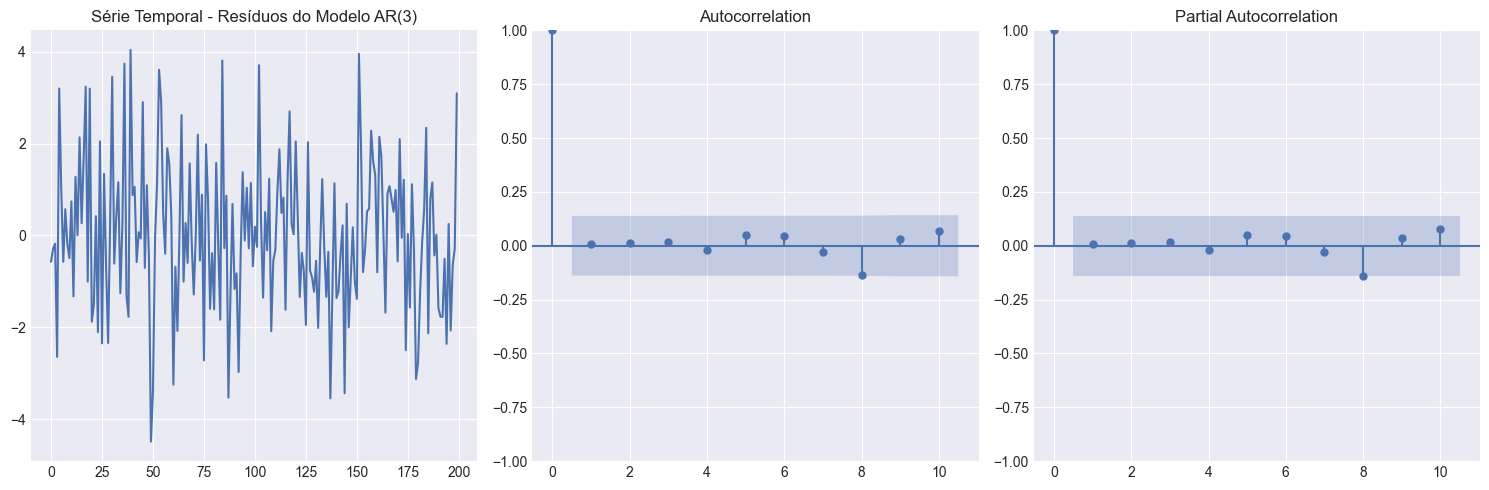

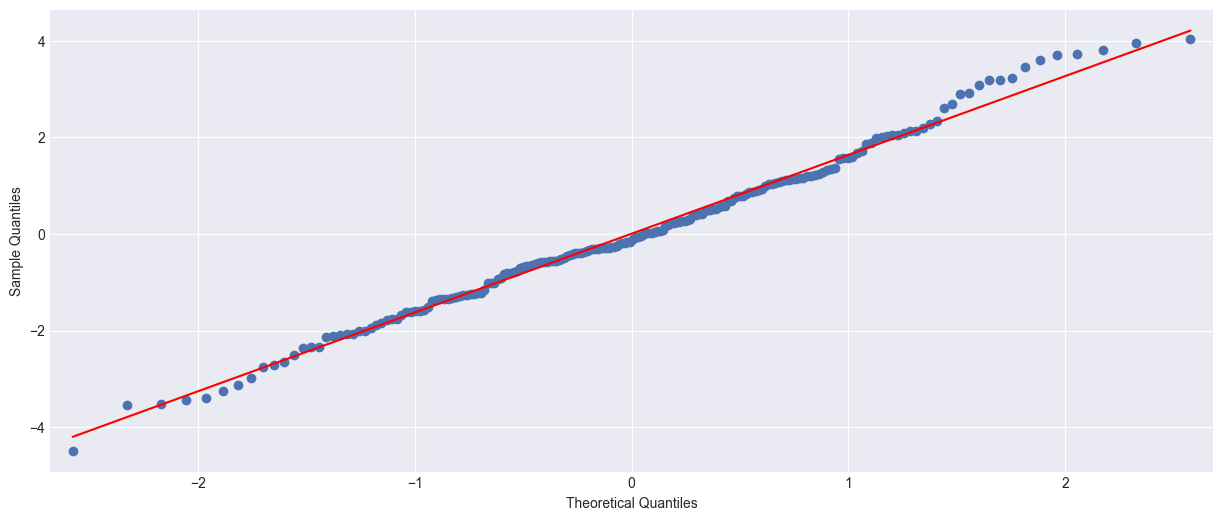

In [14]:
plot_acf_pacf(E_AR, title='Resíduos do Modelo AR(3)')
sm.qqplot(E_AR, line='s')
plt.show()

### Testes Estatísticos para Validar o Modelo AR

Temos que verificar se nossos resíduos são:

-   Normais

-   Independentes

-   Estacionários

In [15]:
ljung_box_result = sm.stats.acorr_ljungbox(E_AR, lags=[20], return_df=True)
print('Teste de Independência - Ljung-Box:')
print(ljung_box_result)

Teste de Independência - Ljung-Box:
      lb_stat  lb_pvalue
20  16.516771   0.684092


**Teste de Normalidade - Shapiro-Wilk**

In [16]:
shapiro_stat, shapiro_p_value = shapiro(E_AR)
print('Teste de Normalidade - Shapiro-Wilk:')
print(f'Estatística do teste: {shapiro_stat:.4f}')
print(f'p-valor: {shapiro_p_value:.4f}')

Teste de Normalidade - Shapiro-Wilk:
Estatística do teste: 0.9920
p-valor: 0.3428
